In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.gridspec as gridspec

2025-09-06 06:22:18.321907: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-06 06:22:18.326740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-06 06:22:18.342949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757139738.373060   93316 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757139738.381422   93316 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-06 06:22:18.412724: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
def find_folder_with_inputs(base_folder, target_inputs):
    print(f"🔍 Searching for folder with input columns: {target_inputs}")
    for folder in os.listdir(base_folder):
        print(f"   - Checking folder: {folder}")
        try:
            folder_num = int(folder)
        except ValueError:
            continue
        
        path = os.path.join(base_folder, folder)
        files = [f for f in os.listdir(path) if f.endswith('.pkl')]
        
        for file in files:
            with open(os.path.join(path, file), "rb") as f:
                try:
                    model_bundle = pickle.load(f)
                    if model_bundle.get('input_columns') == target_inputs:
                        print(f"✅ Found matching model in folder: {folder}")
                        return path
                except Exception as e:
                    print(f"⚠️ Error loading {file} in folder {folder}: {e}")
            continue
    print("❌ No matching folder found.")
    return None

def load_model_components(folder, model_id):
    pkl_path = os.path.join(folder, f"model_2_pig_r01_geo_mixed_C_{model_id}.pkl")
    h5_path = os.path.join(folder, f"model_2_pig_r01_geo_mixed_C_{model_id}.h5")

    print(f"📦 Loading model {model_id}")
    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    model = keras.models.load_model(h5_path)

    return {
        'model': model,
        'input_scaler': bundle['input_scaler'],
        'output_scaler': bundle['output_scaler'],
        'input_columns': bundle['input_columns'],
        'output_columns': bundle['output_columns']
    }

def run_grid_and_predict(folder, input_1='heatflux', input_2='gravity_disturbance',
                         val_range_1=(0, 1), val_range_2=(0, 1), num_points=50):
    
    # Create input grid
    print(f"📈 Creating grid between {val_range_1} and {val_range_2} with {num_points} points")
    heat_vals = np.linspace(val_range_1[0], val_range_1[1], num_points)
    grav_vals = np.linspace(val_range_2[0], val_range_2[1], num_points)
    H, G = np.meshgrid(heat_vals, grav_vals)
    input_grid = np.vstack([H.ravel(), G.ravel()]).T

    print(f"🧮 Total points to evaluate: {input_grid.shape[0]}")
    predictions = []

    # Loop over all models in folder
    pkl_files = sorted([f for f in os.listdir(folder) if f.endswith('.pkl')])
    print(f"🧠 Ensemble size: {len(pkl_files)} models")

    for file in pkl_files:
        model_id = file.split('_')[-1].split('.')[0]
        try:
            components = load_model_components(folder, model_id)
        except Exception as e:
            print(f"⚠️ Skipping model_{model_id} due to error: {e}")
            continue
        
        model = components['model']
        input_scaler = components['input_scaler']
        output_scaler = components['output_scaler']

        # Scale inputs
        scaled_inputs = input_scaler.transform(input_grid)
        preds = model.predict(scaled_inputs).reshape(-1, 1)
        preds_unscaled = output_scaler.inverse_transform(preds).reshape(-1)

        print(f"   🔹 Model {model_id} prediction range: [{preds_unscaled.min():.3f}, {preds_unscaled.max():.3f}]")
        predictions.append(preds_unscaled)

    predictions = np.array(predictions)
    median_preds = np.median(predictions, axis=0)
    print(f"✅ Mean prediction stats: min={median_preds.min():.3f}, max={median_preds.max():.3f}, mean={median_preds.mean():.3f}")
    
    return H, G, median_preds.reshape(H.shape)

In [3]:
if __name__ == "__main__":
    base_folder = 'mlp_ensemble_englacial_4'
    target_inputs = ['heatflux', 'mag_anomaly']

    # Step 1: Find folder
    target_folder = find_folder_with_inputs(base_folder, target_inputs)

    if target_folder:
        # Step 2–4: Run grid + predict
        H, G, mean_output = run_grid_and_predict(
            target_folder,
            val_range_1=(56, 73),  # Customize based on actual min/max
            val_range_2=(-220, 220), # get from pdf plot
            num_points=100
        )

        # Optional: peek at one row of data
        print("🔎 Sample output row:", mean_output[0, :5])

        

🔍 Searching for folder with input columns: ['heatflux', 'mag_anomaly']
   - Checking folder: 2075614561769015715


2025-09-06 06:22:32.141218: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


   - Checking folder: 8841118694353468863
   - Checking folder: summary_6854.csv
   - Checking folder: -5339226243799483527
   - Checking folder: -2740619310642310765
   - Checking folder: r2_stats_list.pkl
   - Checking folder: -1003785993143526674
   - Checking folder: .ipynb_checkpoints
   - Checking folder: -4485138934457262928
   - Checking folder: -98631542902948751
   - Checking folder: r2_adjusted_stats_list.pkl
   - Checking folder: -6128423182858710439
   - Checking folder: 2527493322429984672
   - Checking folder: 3201346191993881778
   - Checking folder: -6180078295567716747
   - Checking folder: 1366113751283818998
   - Checking folder: summary_20250223_084249.csv
   - Checking folder: summary_20250308_232008.csv
   - Checking folder: mse_stats_list.pkl
   - Checking folder: 5498412892654769408
   - Checking folder: 5281767268982107043
   - Checking folder: -7723818363851199316
✅ Found matching model in folder: -7723818363851199316
📈 Creating grid between (56, 73) and (-22

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
   🔹 Model 0 prediction range: [-3.091, 55.419]
📦 Loading model 1


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
   🔹 Model 1 prediction range: [-3.740, 35.983]
📦 Loading model 2


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
   🔹 Model 5 prediction range: [-2.946, 76.007]
📦 Loading model 6


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
   🔹 Model 6 prediction range: [-3.890, 84.740]
📦 Loading model 7


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
   🔹 Model 7 prediction range: [-3.331, 48.266]
📦 Loading model 8


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
   🔹 Model 8 prediction range: [-5.306, 69.231]
📦 Loading model 9


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
   🔹 Model 9 prediction range: [-4.009, 76.418]
✅ Mean prediction stats: min=-2.868, max=55.856, mean=5.587
🔎 Sample output row: [2.1763334 2.144383  2.1035573 2.0540597 2.03394  ]


In [4]:
def plot_heatmap(X, Y, Z, xlabel='heatflux', ylabel='gravity_disturbance'):
    print("🖼️ Plotting heatmap with contour lines...")
    plt.figure(figsize=(8, 6))
    # Filled contours (heatmap)
    contourf = plt.contourf(X, Y, Z, levels=100, cmap='viridis')
    # Contour lines
    contours = plt.contour(X, Y, Z, levels=25, colors='black', linewidths=0.8)
    plt.clabel(contours, inline=True, fontsize=8, fmt="%.2f")  # Optional: label the lines
    plt.colorbar(contourf) #, label='Model Output')
    plt.xlabel(xlabel, fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    #plt.title('Median Ensemble Prediction Heatmap')
    plt.tight_layout()
    plt.show()

🖼️ Plotting heatmap with contour lines...


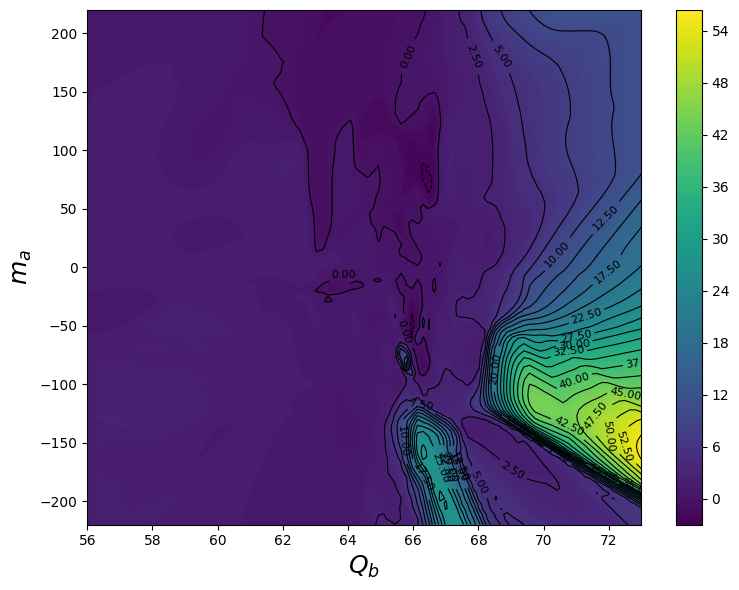

In [5]:
# Step 5: Plot
plot_heatmap(H, G, mean_output, xlabel=r"$Q_b$", ylabel=r"$m_a$")

In [6]:
def process_csv(filename):
    df = pd.read_csv(filename, index_col=0)
    df = df.sample(frac=1).reset_index(drop=True)
    df['vel_mag'] = np.sqrt(df['x_velocity_initial']**2 + df['y_velocity_initial']**2)
    df['driving_stress'] = df['h'] * 9.8 * df['mag_s']
    df['s/h'] = df['s'] / df['h']
    df['b/h'] = df['b'] / df['h']
    df['mag_s/mag_h'] = df['mag_s'] / df['mag_h']
    df['mag_b/mag_h'] = df['mag_b'] / df['mag_h']
    df['tu1'] = df['driving_stress'] / df['vel_mag']
    df['tu2'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 2))
    df['tu3'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 3))
    df['tu4'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 4))
    df['tu5'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 5))
    df['1/tu1'] = df['vel_mag'] / df['driving_stress']
    df['1/tu2'] = (df['vel_mag'] ** (1 / 2)) / df['driving_stress']
    df['1/tu3'] = (df['vel_mag'] ** (1 / 3)) / df['driving_stress']
    df['1/tu4'] = (df['vel_mag'] ** (1 / 4)) / df['driving_stress']
    df['1/tu5'] = (df['vel_mag'] ** (1 / 5)) / df['driving_stress']
    df['1/tu6'] = (df['vel_mag'] ** (1 / 6)) / df['driving_stress']
    df['invariant1_pow2'] = np.abs(df['invariant1']) ** (1 / 2)
    df['invariant1_pow3'] = np.abs(df['invariant1']) ** (1 / 3)
    df['invariant2_pow2'] = np.abs(df['invariant2']) ** (1 / 2)
    df['invariant2_pow3'] = np.abs(df['invariant2']) ** (1 / 3)
    #df['phi'] = df.apply(lambda row: get_phi(row['h'], row['s']), axis=1)
    #df['C_total'] = C0 * df['phi']*np.exp(df['C'])
    return df

In [7]:
df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')
df_amundsen = process_csv('regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12.csv')

In [16]:
def plot_heatmap_with_pdfs(
    H, G, Z,
    df_pig, df_thwaites, df_dotson, df_amundsen,
    xlabel=r"$Q_b$", ylabel=r"$g_b$"
):
    """
    Plot heatmap with contour lines + marginal PDFs for PIG, Thwaites, Dotson, Amundsen.

    Behavior:
    - Heatmap colors are CLIPPED to [-2, 5].
    - Contour lines/labels extend to full data range.
    - Axis limits set to the 1st–99th percentiles of H (x) and G (y).
    - Heatmap shows x/y labels; PDFs do NOT repeat them.
    - Marginal PDFs flipped outward.
    - PDF legend bottom-left.
    - PIG extent box drawn on heatmap.
    - Separate font sizes for PDF base (x) ticks and height (y) ticks.
    - Colorbar shows only title “C” at the top.
    """
    print("🖼️ Plotting heatmap with marginal PDFs...")

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import seaborn as sns
    from matplotlib.ticker import MaxNLocator
    from matplotlib.patches import Rectangle
    from matplotlib.colors import Normalize

    # --- Font sizes ---
    fs_label_main = 22      # main x/y label
    fs_tick_main  = 18      # main tick labels
    fs_pdf_label  = 10      # axis-label text "Density" on PDFs
    fs_tick_pdf_x = 24      # tick labels along PDF base (x-axis)
    fs_tick_pdf_y = 10      # tick labels along PDF height (y-axis)
    fs_cbar_tick  = 16      # colorbar tick labels
    fs_cbar_title = 25      # colorbar title
    fs_legend     = 14      # legend text
    fs_contourlab = 10      # contour labels
    fs_pig_text   = 20      # PIG box text

    # Close prior figures and layout
    plt.close('all')
    fig = plt.figure(figsize=(12.5, 9.5), constrained_layout=True)

    # Grid: y-PDF (col 0), main (col 1), colorbar (col 2)
    gs = gridspec.GridSpec(
        2, 3,
        width_ratios=[1.2, 4.9, 0.34],
        height_ratios=[4.4, 1.35],
        hspace=0.05, wspace=0.05,
        figure=fig
    )

    # --- Main heatmap ---
    ax_main = fig.add_subplot(gs[0, 1])

    Hg, Gg = (H, G)
    if getattr(H, "ndim", 1) == 1 and getattr(G, "ndim", 1) == 1:
        Hg, Gg = np.meshgrid(H, G)

    vmin, vmax = -2, 5
    norm = Normalize(vmin=vmin, vmax=vmax)

    levels_f = np.linspace(vmin, vmax, 101)
    contourf = ax_main.contourf(Hg, Gg, Z, levels=levels_f, cmap='viridis', norm=norm)

    z_lo, z_hi = np.nanpercentile(np.asarray(Z).ravel(), [1, 99])
    levels_c = np.linspace(z_lo, z_hi, 25)
    contours = ax_main.contour(Hg, Gg, Z, levels=levels_c, colors='black', linewidths=0.8)
    ax_main.clabel(contours, inline=True, fontsize=fs_contourlab, fmt="%.2f")

    # Colorbar
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(contourf, cax=cax)
    cbar.set_ticks(np.linspace(vmin, vmax, 8))
    cbar.ax.tick_params(labelsize=fs_cbar_tick)
    cbar.ax.set_title("C", fontsize=fs_cbar_title, pad=6)

    # Labels and ticks
    ax_main.set_xlabel(xlabel, fontsize=fs_label_main)
    ax_main.set_ylabel(ylabel, fontsize=fs_label_main)
    ax_main.set_aspect('auto')
    ax_main.tick_params(direction='in', length=4, labelsize=fs_tick_main)
    ax_main.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax_main.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # Axis limits (robust)
    x_vals = np.asarray(H).ravel() if getattr(H, "ndim", 1) != 1 else np.asarray(H)
    y_vals = np.asarray(G).ravel() if getattr(G, "ndim", 1) != 1 else np.asarray(G)
    x1, x99 = np.nanpercentile(x_vals, [1, 99])
    y1, y99 = np.nanpercentile(y_vals, [1, 99])
    ax_main.set_xlim(x1, x99)
    ax_main.set_ylim(y1, y99)

    # --- PIG bounding box ---
    def safe_percentiles(series, q=(1, 99)):
        s = series.dropna()
        return np.percentile(s.values, q) if s.size > 0 else None

    if ("heatflux" in df_pig) and ("mag_anomaly" in df_pig):
        px = safe_percentiles(df_pig["heatflux"])
        py = safe_percentiles(df_pig["mag_anomaly"])
        if (px is not None) and (py is not None):
            rect_x, rect_y = min(px), min(py)
            rect_w, rect_h = abs(px[1] - px[0]), abs(py[1] - py[0])
            pig_rect = Rectangle(
                (rect_x, rect_y), rect_w, rect_h,
                facecolor=(1, 1, 1, 0.08),
                edgecolor='white', linewidth=1.8, linestyle='-', zorder=5
            )
            ax_main.add_patch(pig_rect)
            ax_main.text(
                rect_x, rect_y, " PIG ",
                color='black', fontsize=fs_pig_text, va='bottom', ha='left',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, boxstyle='round,pad=0.2'),
                zorder=6
            )

    # --- Bottom PDF (heatflux / Q_b) ---
    ax_xpdf = fig.add_subplot(gs[1, 1], sharex=ax_main)
    for df, name, color in [
        (df_amundsen, "Amundsen", "gray"),
        (df_thwaites, "Thwaites", "tab:blue"),
        (df_pig, "PIG", "tab:orange"),
        (df_dotson, "Dotson", "tab:green"),
    ]:
        if ("heatflux" in df) and (not df["heatflux"].isnull().all()):
            if name == "Amundsen":
                sns.kdeplot(df["heatflux"], ax=ax_xpdf, linestyle='--', color=color,
                            label=name, linewidth=2, alpha=0.8, fill=False, clip_on=True)
            else:
                sns.kdeplot(df["heatflux"], ax=ax_xpdf, color=color, label=name,
                            fill=True, alpha=0.35, lw=1, clip_on=True)

    ymin, ymax = ax_xpdf.get_ylim()
    ax_xpdf.set_ylim(ymax, ymin)
    ax_xpdf.set_xlabel("")  # no Q_b label here
    ax_xpdf.set_ylabel("Density", fontsize=fs_pdf_label)
    ax_xpdf.tick_params(axis="x", labelbottom=True, direction='in',
                        length=3, labelsize=fs_tick_pdf_x)
    ax_xpdf.tick_params(axis="y", labelsize=fs_tick_pdf_y)
    ax_xpdf.spines['top'].set_visible(False)
    ax_xpdf.spines['right'].set_visible(False)
    ax_xpdf.legend(fontsize=fs_legend, ncol=2, frameon=False, loc='lower left')
    ax_xpdf.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_xpdf.xaxis.set_major_locator(MaxNLocator(nbins=6))

    # --- Left PDF (mag_anomaly / g_b) ---
    ax_ypdf = fig.add_subplot(gs[0, 0], sharey=ax_main)
    for df, name, color in [
        (df_amundsen, "Amundsen", "gray"),
        (df_thwaites, "Thwaites", "tab:blue"),
        (df_pig, "PIG", "tab:orange"),
        (df_dotson, "Dotson", "tab:green"),
    ]:
        if ("mag_anomaly" in df) and (not df["mag_anomaly"].isnull().all()):
            if name == "Amundsen":
                sns.kdeplot(y=df["mag_anomaly"], ax=ax_ypdf, linestyle='--', color=color,
                            linewidth=2, alpha=0.8, fill=False, clip_on=True)
            else:
                sns.kdeplot(y=df["mag_anomaly"], ax=ax_ypdf, color=color,
                            fill=True, alpha=0.35, lw=1, clip_on=True)

    xmin, xmax = ax_ypdf.get_xlim()
    ax_ypdf.set_xlim(xmax, xmin)
    ax_ypdf.set_xlabel("Density", fontsize=fs_pdf_label)
    ax_ypdf.set_ylabel("")  # no g_b label here
    ax_ypdf.tick_params(axis="y", labelleft=True, direction='in',
                        length=3, labelsize=fs_tick_pdf_x)
    ax_ypdf.tick_params(axis="x", labelsize=fs_tick_pdf_y)
    ax_ypdf.spines['top'].set_visible(False)
    ax_ypdf.spines['right'].set_visible(False)
    ax_ypdf.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_ypdf.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # --- Hide overlapping tick labels on main axes ---
    plt.setp(ax_main.get_xticklabels(), visible=False)
    plt.setp(ax_main.get_yticklabels(), visible=False)

    # Sync limits
    x_lo, x_hi = ax_main.get_xlim()
    y_lo, y_hi = ax_main.get_ylim()
    ax_xpdf.set_xlim(x_lo, x_hi)
    ax_ypdf.set_ylim(y_lo, y_hi)

    plt.show()


🖼️ Plotting heatmap with marginal PDFs...


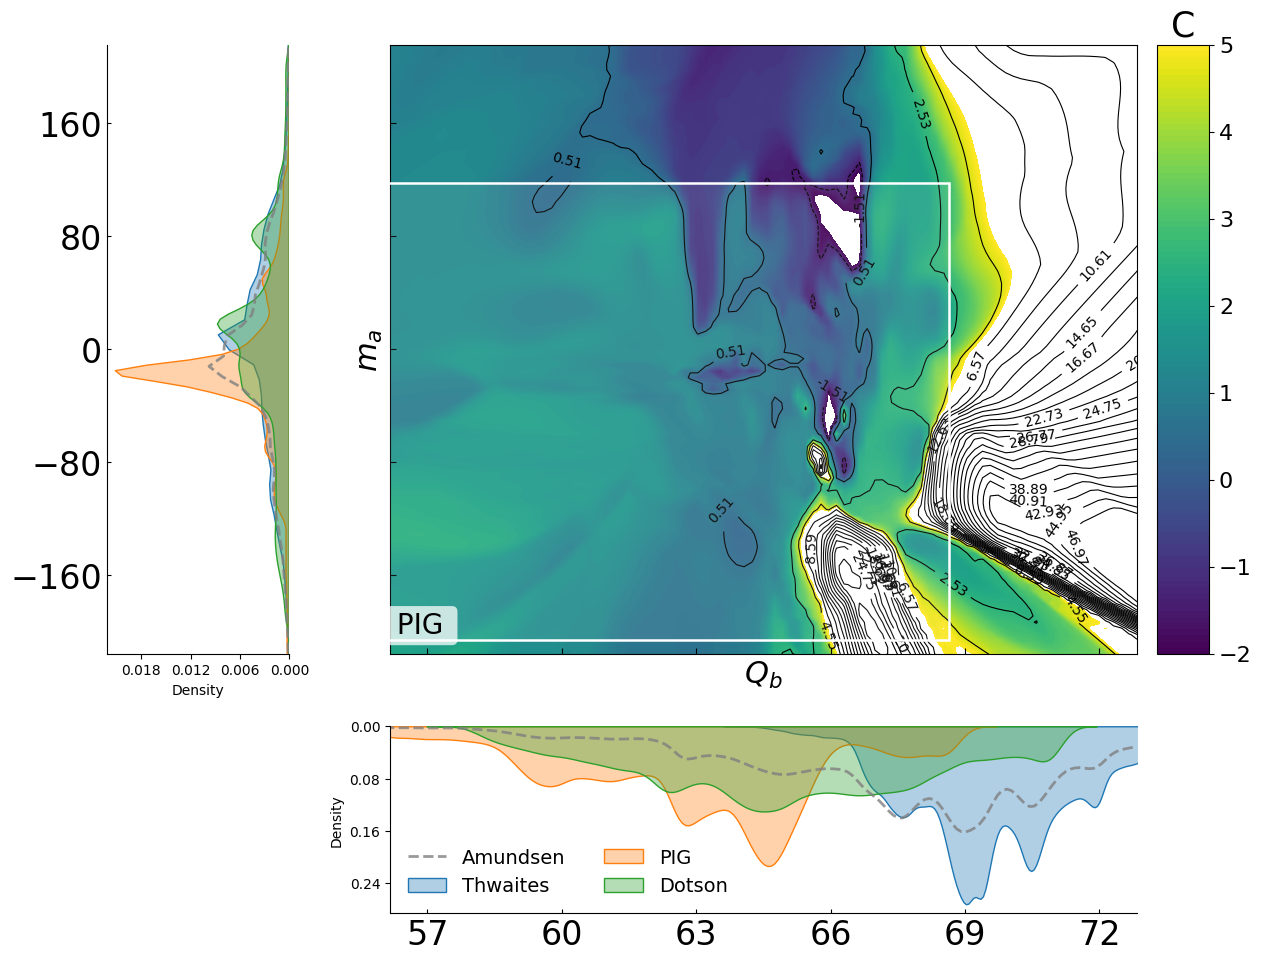

In [17]:
plot_heatmap_with_pdfs(H, G, mean_output, 
                       df_pig, df_thwaites, df_dotson, df_amundsen,
                       xlabel=r"$Q_b$", ylabel=r"$m_a$")